In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# pip install corner
import corner

BASE_OUT = "/home/geng/Codes/lensing_cosmo/jax01/output_test40"

small_labels = {
    "wcdm": "test140_small_wcdm",
    "w0wa": "test140_small_w0wa",
    "wphi": "test140_small_wphi",
}

tail_keys = [
    "gamma0", "gamma_s", "log_sig_g",
    "delta0", "delta_s", "log_sig_d",
    "beta0", "log_sig_b",
]

def head_keys_for(model):
    if model == "wcdm":
        return ["Om", "w"]
    if model == "w0wa":
        return ["Om", "w0", "wa"]
    if model == "wphi":
        return ["Om", "w0", "alpha"]
    raise ValueError(f"unknown model: {model}")

def load_samples(npz_path, keys):
    data = np.load(npz_path)
    missing = [k for k in keys if k not in data.files]
    if missing:
        raise KeyError(f"npz 文件缺少 keys: {missing}\n可用: {data.files}")
    samples = np.vstack([data[k] for k in keys]).T
    diverging = data["diverging"].astype(bool) if "diverging" in data.files else None
    return samples, diverging

# -------------------------
# 小样本: corner + diverging red
# -------------------------
for model, label in small_labels.items():
    npz_path = os.path.join(BASE_OUT, f"posterior_minimal_chunks_{label}.npz")
    keys = head_keys_for(model) + tail_keys
    samples, diverging = load_samples(npz_path, keys)

    burn = int(0.2 * samples.shape[0])
    samples2 = samples[burn:]
    diverging2 = diverging[burn:] if diverging is not None else None

    fig = corner.corner(
        samples2 if diverging2 is None else samples2[~diverging2],
        labels=keys,
        show_titles=True,
        title_fmt=".3f",
        quantiles=[0.16, 0.5, 0.84],
        color="C0",
    )

    if diverging2 is not None and np.any(diverging2):
        corner.corner(
            samples2[diverging2],
            fig=fig,
            color="red",
            show_titles=False,
        )

    corner_path = os.path.join(BASE_OUT, f"corner_small_{label}.png")
    fig.savefig(corner_path, dpi=200)
    plt.close(fig)
    print("Saved:", corner_path)



Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output/getdist_full_sgl140a_wcdm_main.png


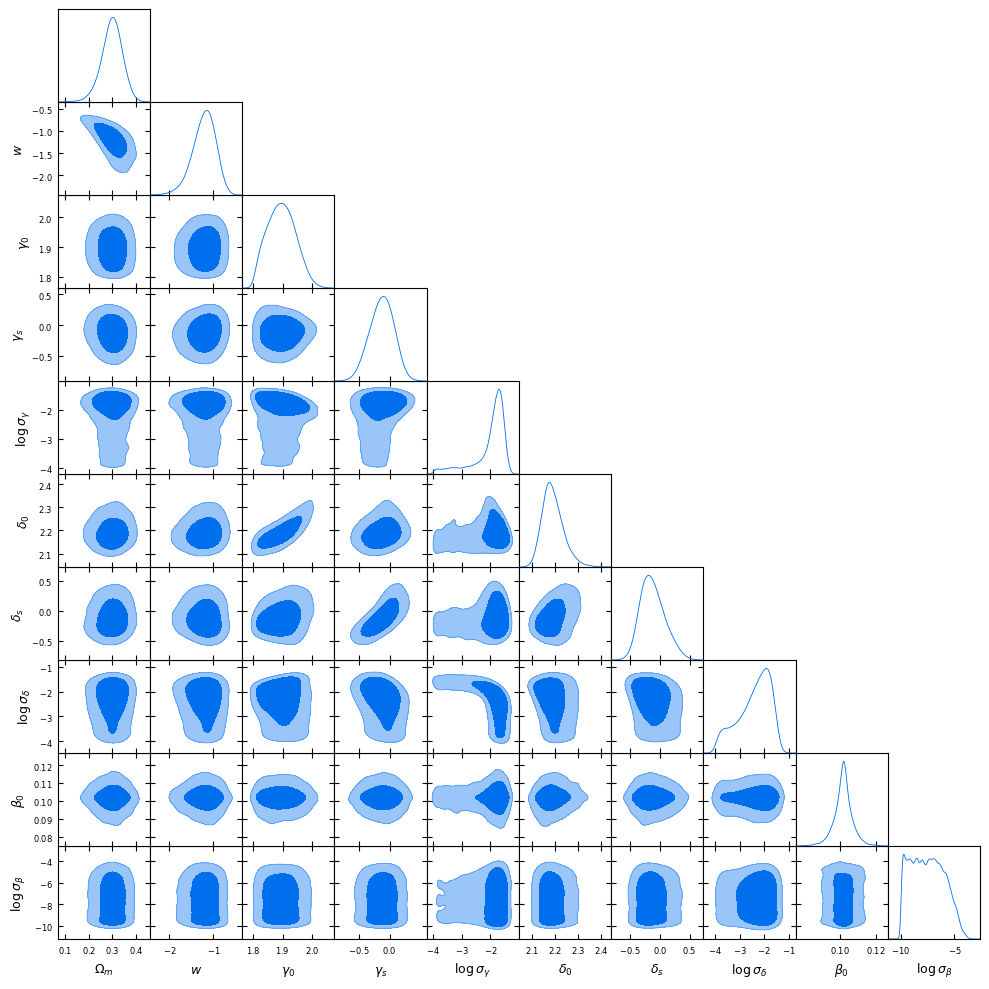

In [1]:
import os
import numpy as np

# pip install getdist
from getdist import MCSamples, plots as gdplots

BASE_OUT = "/home/geng/Codes/lensing_cosmo/jax01/output"

full_labels = {
    "wcdm": "sgl140a_wcdm_main",
    # "w0wa": "test140_full_w0wa",
    # "wphi": "test140_full_wphi",
}

tail_keys = [
    "gamma0", "gamma_s", "log_sig_g",
    "delta0", "delta_s", "log_sig_d",
    "beta0", "log_sig_b",
]

def head_keys_for(model):
    if model == "wcdm":
        return ["Om", "w"]
    if model == "w0wa":
        return ["Om", "w0", "wa"]
    if model == "wphi":
        return ["Om", "w0", "alpha"]
    raise ValueError(f"unknown model: {model}")

def load_samples(npz_path, keys):
    data = np.load(npz_path)
    missing = [k for k in keys if k not in data.files]
    if missing:
        raise KeyError(f"npz 文件缺少 keys: {missing}\n可用: {data.files}")
    samples = np.vstack([data[k] for k in keys]).T
    return samples

name_map = {
    "Om": "Om", "w": "w", "w0": "w0", "wa": "wa", "alpha": "alpha",
    "gamma0": "gamma0", "gamma_s": "gamma_s", "log_sig_g": "log_sig_g",
    "delta0": "delta0", "delta_s": "delta_s", "log_sig_d": "log_sig_d",
    "beta0": "beta0", "log_sig_b": "log_sig_b",
}
label_map = {
    "Om": r"\Omega_m",
    "w": r"w",
    "w0": r"w_0",
    "wa": r"w_a",
    "alpha": r"\alpha",
    "gamma0": r"\gamma_0",
    "gamma_s": r"\gamma_s",
    "log_sig_g": r"\log\sigma_\gamma",
    "delta0": r"\delta_0",
    "delta_s": r"\delta_s",
    "log_sig_d": r"\log\sigma_\delta",
    "beta0": r"\beta_0",
    "log_sig_b": r"\log\sigma_\beta",
}

# -------------------------
# 大样本: getdist
# -------------------------
for model, label in full_labels.items():
    npz_path = os.path.join(BASE_OUT, f"posterior_minimal_chunks_{label}.npz")
    keys = head_keys_for(model) + tail_keys
    samples = load_samples(npz_path, keys)

    burn = int(0.5 * samples.shape[0])
    samples2 = samples[burn:]

    names = [name_map[k] for k in keys]
    labels = [label_map.get(k, k) for k in keys]

    mc = MCSamples(
        samples=samples2,
        names=names,
        labels=labels,
        label=label,
    )

    g = gdplots.get_subplot_plotter(width_inch=10)
    g.triangle_plot(
        [mc],
        filled=True,
        # title_limit=1,
    )

    triangle_path = os.path.join(BASE_OUT, f"getdist_full_{label}.png")
    g.export(triangle_path)
    print("Saved:", triangle_path)



Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output/getdist_full_sgl140_w0wa_main_accept0.97.png


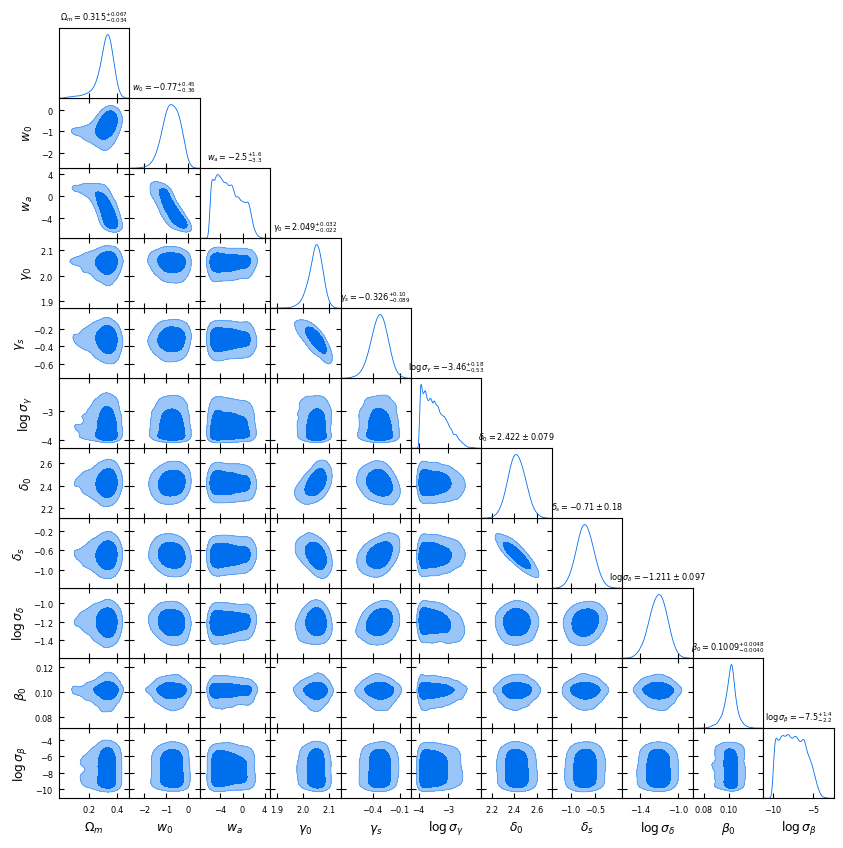

In [ ]:
import os
import numpy as np

# pip install getdist
from getdist import MCSamples, plots as gdplots

BASE_OUT = "/home/geng/Codes/lensing_cosmo/jax01/output"

full_labels = {
    # "wcdm": "sgl140a_wcdm_main",
    "w0wa": "sgl140_w0wa_main_accept0.97",
    # "wphi": "test140_full_wphi",
}

tail_keys = [
    "gamma0", "gamma_s", "log_sig_g",
    "delta0", "delta_s", "log_sig_d",
    "beta0", "log_sig_b",
]

def head_keys_for(model):
    if model == "wcdm":
        return ["Om", "w"]
    if model == "w0wa":
        return ["Om", "w0", "wa"]
    if model == "wphi":
        return ["Om", "w0", "alpha"]
    raise ValueError(f"unknown model: {model}")

def load_samples(npz_path, keys):
    data = np.load(npz_path)
    missing = [k for k in keys if k not in data.files]
    if missing:
        raise KeyError(f"npz 文件缺少 keys: {missing}\n可用: {data.files}")
    samples = np.vstack([data[k] for k in keys]).T
    return samples

name_map = {
    "Om": "Om", "w": "w", "w0": "w0", "wa": "wa", "alpha": "alpha",
    "gamma0": "gamma0", "gamma_s": "gamma_s", "log_sig_g": "log_sig_g",
    "delta0": "delta0", "delta_s": "delta_s", "log_sig_d": "log_sig_d",
    "beta0": "beta0", "log_sig_b": "log_sig_b",
}
label_map = {
    "Om": r"\Omega_m",
    "w": r"w",
    "w0": r"w_0",
    "wa": r"w_a",
    "alpha": r"\alpha",
    "gamma0": r"\gamma_0",
    "gamma_s": r"\gamma_s",
    "log_sig_g": r"\log\sigma_\gamma",
    "delta0": r"\delta_0",
    "delta_s": r"\delta_s",
    "log_sig_d": r"\log\sigma_\delta",
    "beta0": r"\beta_0",
    "log_sig_b": r"\log\sigma_\beta",
}

# -------------------------
# 大样本: getdist
# -------------------------
for model, label in full_labels.items():
    npz_path = os.path.join(BASE_OUT, f"posterior_minimal_chunks_{label}.npz")
    keys = head_keys_for(model) + tail_keys
    samples = load_samples(npz_path, keys)

    burn = int(0.5 * samples.shape[0])
    samples2 = samples[burn:]

    names = [name_map[k] for k in keys]
    labels = [label_map.get(k, k) for k in keys]

    mc = MCSamples(
        samples=samples2,
        names=names,
        labels=labels,
        label=label,
    )

    g = gdplots.get_subplot_plotter(width_inch=10)
    g.triangle_plot(
        [mc],
        filled=True,
        # title_limit=1,
    )

    triangle_path = os.path.join(BASE_OUT, f"getdist_full_{label}.png")
    g.export(triangle_path)
    print("Saved:", triangle_path)



Removed no burn in
Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output/getdist_overlay_wcdm_vs_w0wa.png


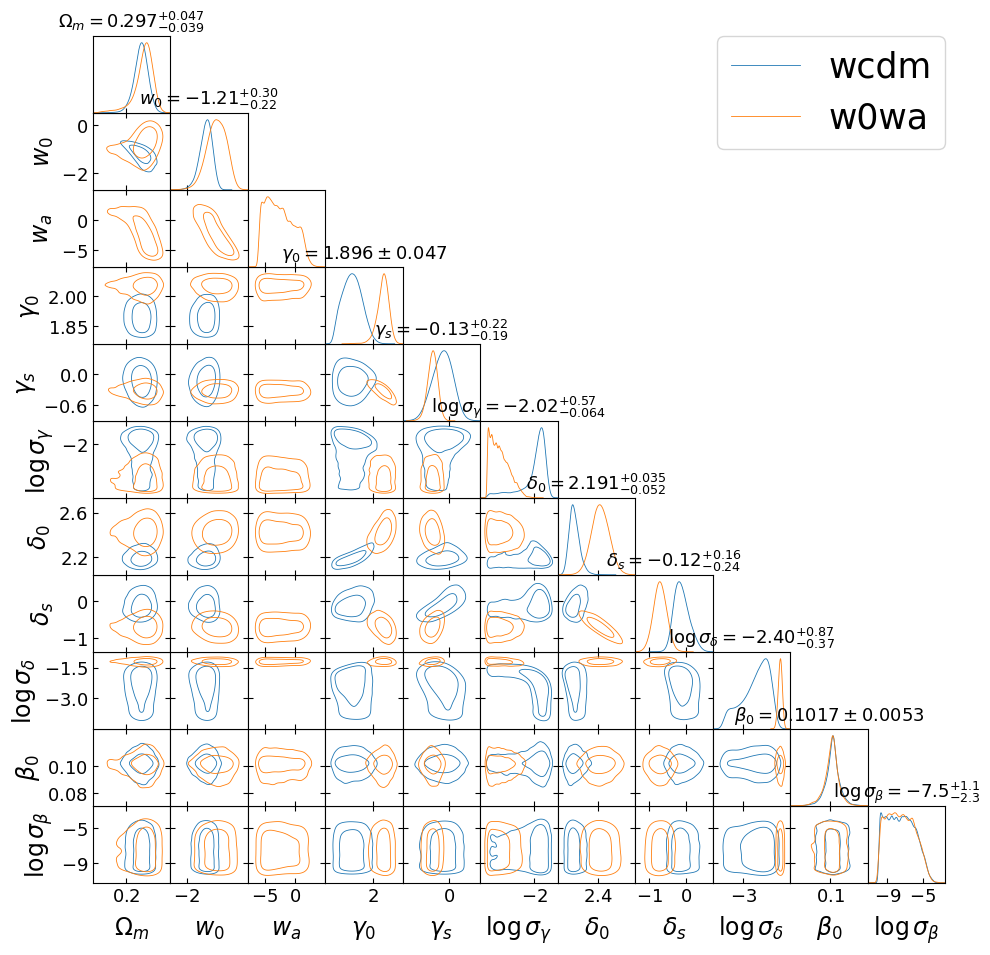

In [1]:
import os
import numpy as np
from getdist import MCSamples, plots as gdplots

BASE_OUT = "/home/geng/Codes/lensing_cosmo/jax01/output"

labels = {
    "wcdm": "sgl140a_wcdm_main",
    "w0wa": "sgl140_w0wa_main_accept0.97",
}

tail_keys = [
    "gamma0", "gamma_s", "log_sig_g",
    "delta0", "delta_s", "log_sig_d",
    "beta0", "log_sig_b",
]

def keys_for(model):
    # wcdm: 用 w0 统一命名，和 w0wa 对齐；wa 缺失会在对应子图留空
    if model == "wcdm":
        return ["Om", "w0"] + tail_keys, ["Om", "w"] + tail_keys
    if model == "w0wa":
        ks = ["Om", "w0", "wa"] + tail_keys
        return ks, ks
    raise ValueError(model)

label_map = {
    "Om": r"\Omega_m",
    "w0": r"w_0",
    "wa": r"w_a",
    "gamma0": r"\gamma_0",
    "gamma_s": r"\gamma_s",
    "log_sig_g": r"\log\sigma_\gamma",
    "delta0": r"\delta_0",
    "delta_s": r"\delta_s",
    "log_sig_d": r"\log\sigma_\delta",
    "beta0": r"\beta_0",
    "log_sig_b": r"\log\sigma_\beta",
}

roots = []
for model in ["wcdm", "w0wa"]:
    npz_path = os.path.join(BASE_OUT, f"posterior_minimal_chunks_{labels[model]}.npz")
    plot_keys, read_keys = keys_for(model)

    data = np.load(npz_path)
    miss = [k for k in read_keys if k not in data.files]
    if miss:
        raise KeyError(f"{model} 缺少 keys: {miss}\n可用: {data.files}")

    samples = np.vstack([data[k] for k in read_keys]).T
    burn = int(0.5 * samples.shape[0])
    samples = samples[burn:]

    names = plot_keys
    labels_tex = [label_map.get(k, k) for k in plot_keys]
    roots.append(MCSamples(samples=samples, names=names, labels=labels_tex, label=model))

params_to_plot = ["Om", "w0", "wa"] + tail_keys

g = gdplots.get_subplot_plotter(width_inch=11)
g.settings.legend_fontsize = 30
g.settings.axes_labelsize = 22
g.settings.axes_fontsize = 18
g.triangle_plot(
    roots,
    params=params_to_plot,
    filled=False,
    contour_colors=["tab:blue", "tab:orange"],
    legend_labels=["wcdm", "w0wa"],
    legend_loc="upper right",
    title_limit=1,
)

out = os.path.join(BASE_OUT, "getdist_overlay_wcdm_vs_w0wa.png")
g.export(out)
print("Saved:", out)


Removed no burn in
Removed no burn in
Saved: /home/geng/Codes/lensing_cosmo/jax01/output/getdist_overlay_wcdm_vs_w0wa.png


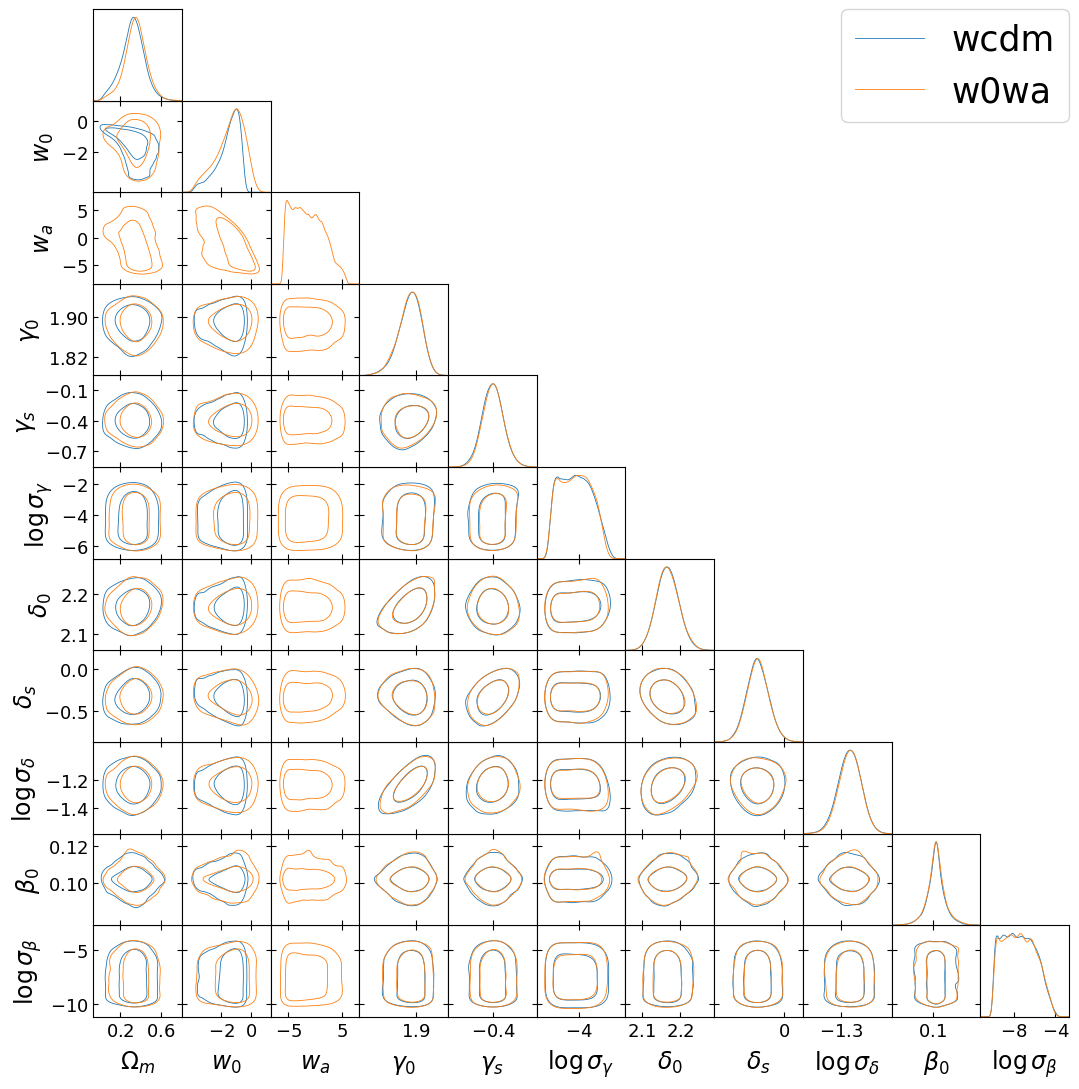

In [2]:
import os
import numpy as np
from getdist import MCSamples, plots as gdplots

BASE_OUT = "/home/geng/Codes/lensing_cosmo/jax01/output"

labels = {
    "wcdm": "sgl146_wcdm_main",
    "w0wa": "sgl146_w0wa_main",
}

tail_keys = [
    "gamma0", "gamma_s", "log_sig_g",
    "delta0", "delta_s", "log_sig_d",
    "beta0", "log_sig_b",
]

def keys_for(model):
    # wcdm: 用 w0 统一命名，和 w0wa 对齐；wa 缺失会在对应子图留空
    if model == "wcdm":
        return ["Om", "w0"] + tail_keys, ["Om", "w"] + tail_keys
    if model == "w0wa":
        ks = ["Om", "w0", "wa"] + tail_keys
        return ks, ks
    raise ValueError(model)

label_map = {
    "Om": r"\Omega_m",
    "w0": r"w_0",
    "wa": r"w_a",
    "gamma0": r"\gamma_0",
    "gamma_s": r"\gamma_s",
    "log_sig_g": r"\log\sigma_\gamma",
    "delta0": r"\delta_0",
    "delta_s": r"\delta_s",
    "log_sig_d": r"\log\sigma_\delta",
    "beta0": r"\beta_0",
    "log_sig_b": r"\log\sigma_\beta",
}

roots = []
for model in ["wcdm", "w0wa"]:
    npz_path = os.path.join(BASE_OUT, f"posterior_minimal_chunks_{labels[model]}.npz")
    plot_keys, read_keys = keys_for(model)

    data = np.load(npz_path)
    miss = [k for k in read_keys if k not in data.files]
    if miss:
        raise KeyError(f"{model} 缺少 keys: {miss}\n可用: {data.files}")

    samples = np.vstack([data[k] for k in read_keys]).T
    burn = int(0.5 * samples.shape[0])
    samples = samples[burn:]

    names = plot_keys
    labels_tex = [label_map.get(k, k) for k in plot_keys]
    roots.append(MCSamples(samples=samples, names=names, labels=labels_tex, label=model))

params_to_plot = ["Om", "w0", "wa"] + tail_keys

g = gdplots.get_subplot_plotter(width_inch=11)
g.settings.legend_fontsize = 30
g.settings.axes_labelsize = 22
g.settings.axes_fontsize = 18
g.triangle_plot(
    roots,
    params=params_to_plot,
    filled=False,
    contour_colors=["tab:blue", "tab:orange"],
    legend_labels=["wcdm", "w0wa"],
    legend_loc="upper right",
    title_limit=0,
)

out = os.path.join(BASE_OUT, "getdist_overlay_wcdm_vs_w0wa.png")
g.export(out)
print("Saved:", out)
